In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score


---

**Data Preparation:**

---

In [2]:
df = pd.read_csv('/content/heart_disease_uci.csv')
df = df.drop(['id'], axis=1)
df

FileNotFoundError: [Errno 2] No such file or directory: '/content/heart_disease_uci.csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 107.9+ KB


In [ ]:
# Remove 'ca' and 'thal' because Nan values > 50%

X = df.drop(['num', 'ca','thal'], axis=1)
y = df['num'].apply(lambda n: 0 if n == 0 else 1)


In [ ]:
X.isnull().sum() / len(df) * 100

,0
age,0.000000
sex,0.000000
dataset,0.000000
cp,0.000000
trestbps,6.413043
chol,3.260870
fbs,9.782609
restecg,0.217391
thalch,5.978261
exang,5.978261


In [ ]:
#create cat and num varible
categorical = df.columns[df.nunique() < 50]
numeric = df.select_dtypes(include=[int, float]).columns[df.select_dtypes(include=[int, float]).nunique() >= 50]


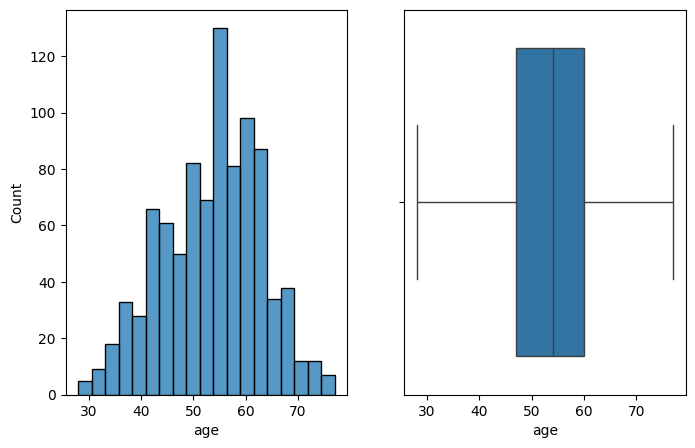

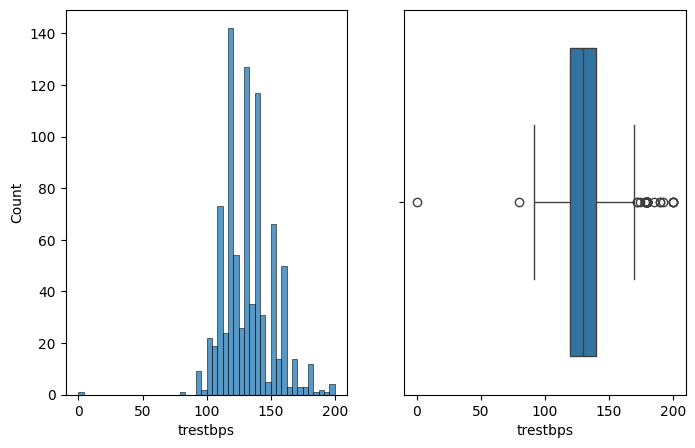

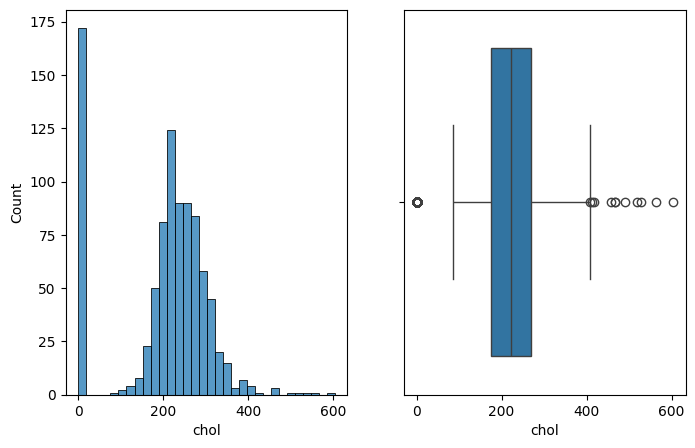

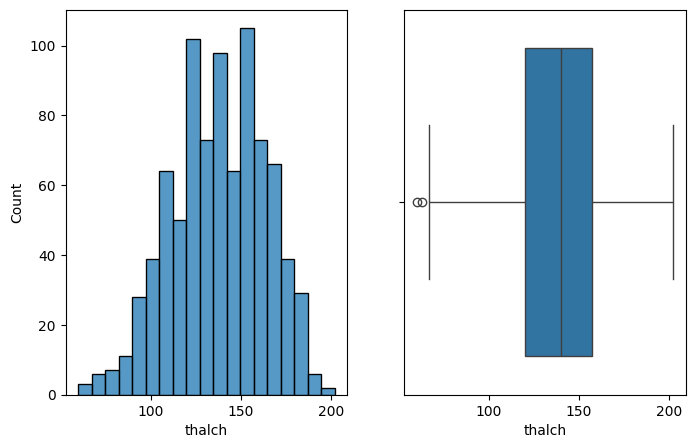

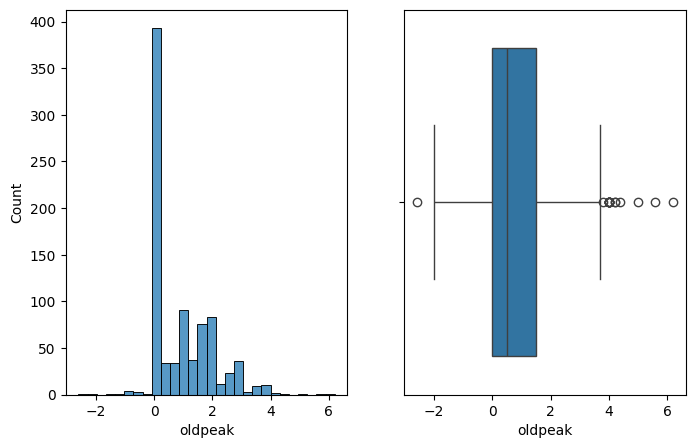

In [ ]:
for feature in numeric:
  fig, axes = plt.subplots(1, 2, figsize=(8, 5))
  sns.histplot(data = df, x=feature, ax=axes[0])
  sns.boxplot(data=df, x=feature, ax=axes[1])
  plt.show()

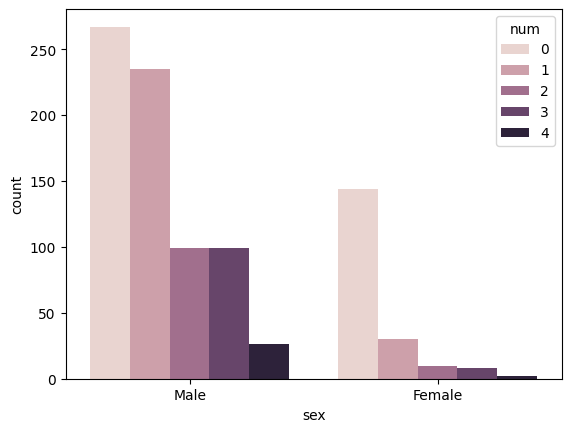

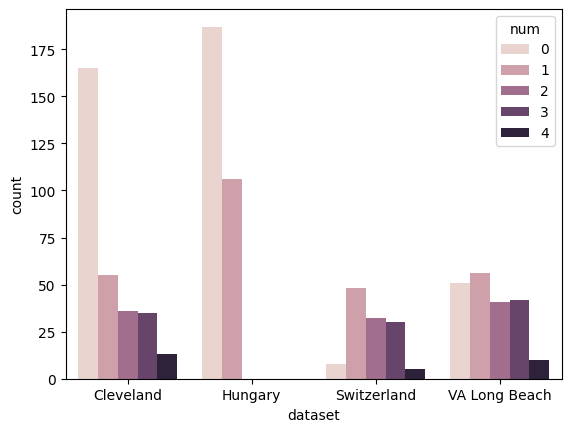

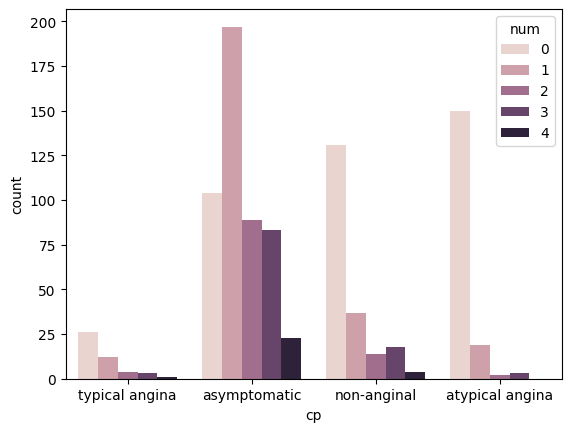

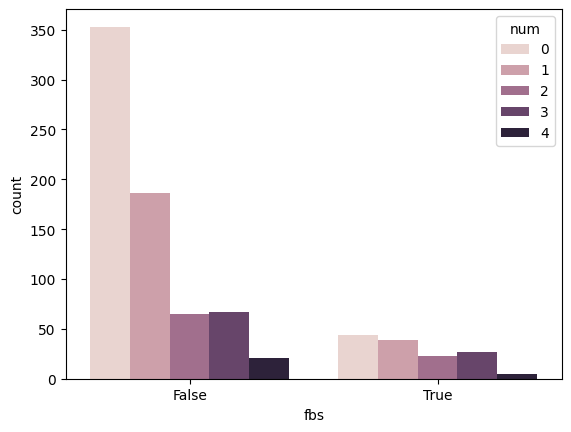

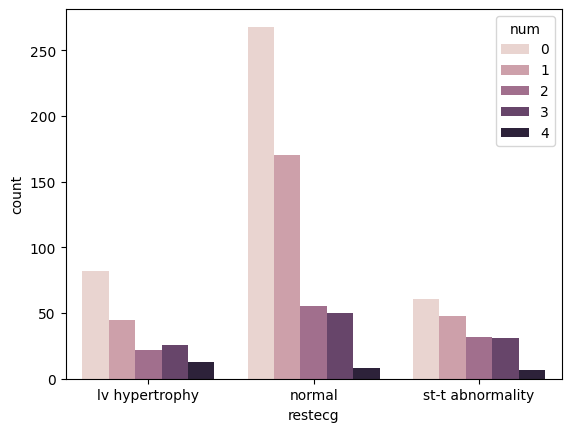

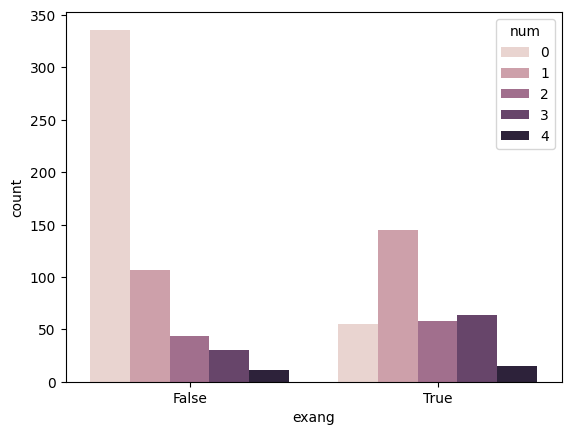

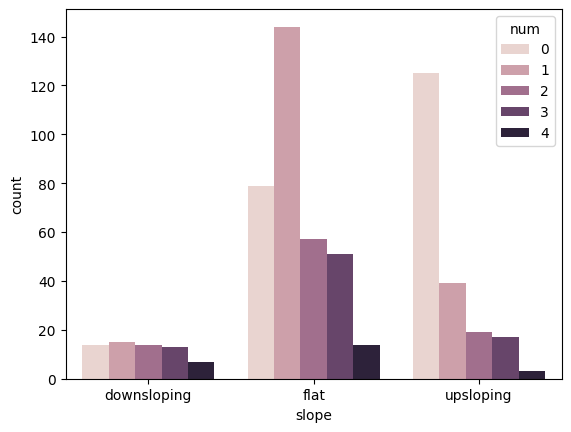

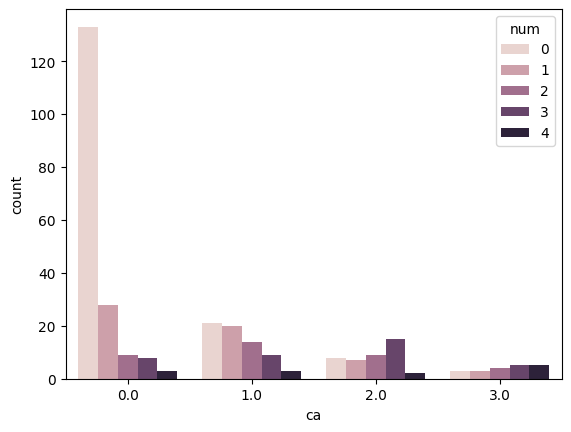

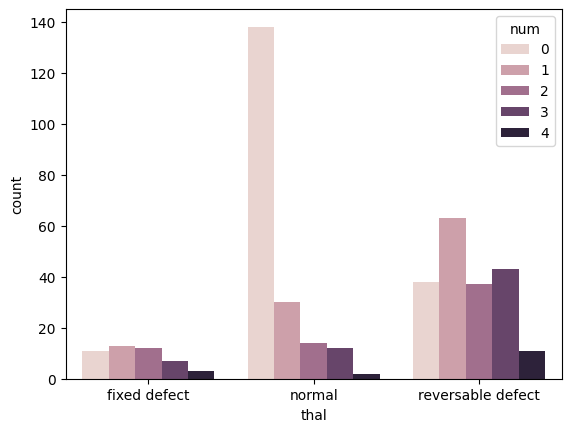

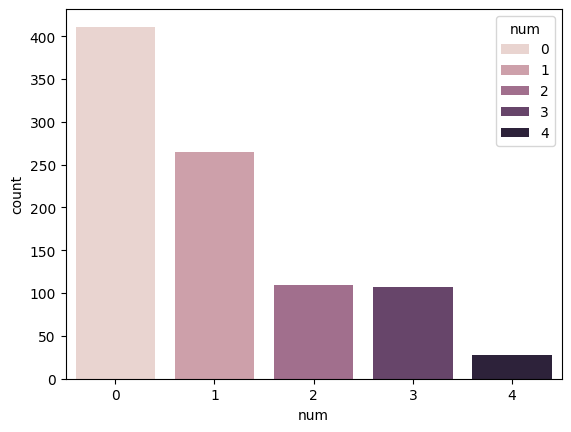

In [ ]:
for feature in categorical:
  sns.countplot(data=df, x=feature, hue='num')
  plt.show()

---

###Find missing values

---

In [ ]:

# Split into numeric and categorical

# Find columns with missing values
missing_cols = X.columns[X.isnull().any()].tolist()

# Numeric columns
num_missing = [col for col in missing_cols if X[col].dtype in ['int64', 'float64']]

# Categorical columns
cat_missing = [col for col in missing_cols if X[col].dtype == 'object']

print("Numeric columns with missing values:", num_missing)
print("Categorical columns with missing values:", cat_missing)

Numeric columns with missing values: ['trestbps', 'chol', 'thalch', 'oldpeak']
Categorical columns with missing values: ['fbs', 'restecg', 'exang', 'slope']


---

###Impute missing values for numeric columns

---

In [ ]:
from sklearn.impute import KNNImputer

# Select only numeric columns with missing values
X_num = X[num_missing]

#  KNN for numeric columns
imputer = KNNImputer()
X_num_imputed = imputer.fit_transform(X_num)

# Return to DataFrame
X_num_filled = pd.DataFrame(X_num_imputed, columns=num_missing, index=X.index)

---

###Impute missing values for categorical columns

---


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Select only categorical columns with missing values
X_cat = X[cat_missing].copy()

for col in X_cat:
    # Fill NaNs with a placeholder if you want to keep "missing" as a separate class
    X_cat[col] = X_cat[col].astype(str).fillna('missing')
    le = LabelEncoder()
    X_cat[col] = le.fit_transform(X_cat[col])

In [ ]:
# Merge filled columns back into the original DataFrame

# Replace numeric columns in X
X.update(X_num_filled)

# Replace categorical columns in X
X.update(X_cat)

# Check for missing values again
print("Missing values after imputation:\n", X.isnull().sum())

Missing values after imputation:
 age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
dtype: int64


---

**Model Training:**

---

In [ ]:
#one-hot encoding
X = pd.get_dummies(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify = y)

NameError: name 'train_test_split' is not defined

In [ ]:

real_num_cols = [col for col in X.columns if X[col].nunique() > 2]

scaler = StandardScaler()
X_train[real_num_cols] = scaler.fit_transform(X_train[real_num_cols])
X_test[real_num_cols] = scaler.transform(X_test[real_num_cols])

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.79      0.77        75
           1       0.85      0.83      0.84       109

    accuracy                           0.81       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.81      0.81      0.81       184



---


**Model Evaluation:**

---

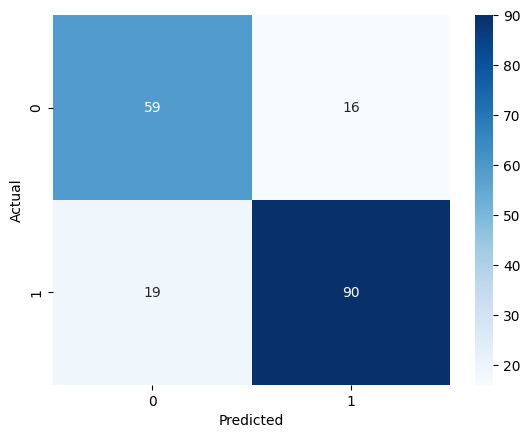

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

* 59 true negatives, 90 true positives, 16 false positives, 19 false negatives.

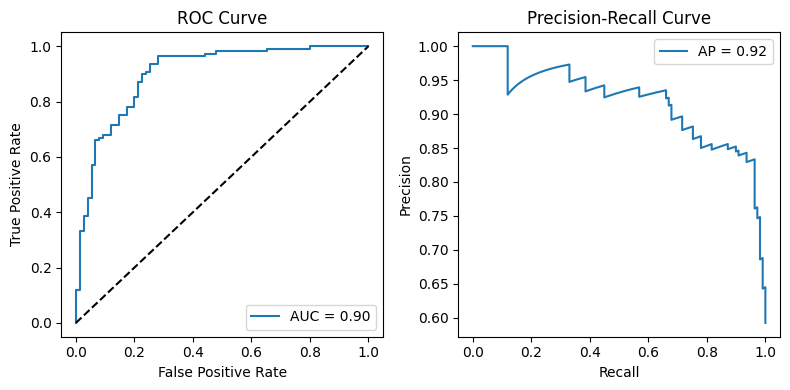

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


y_probs = model.predict_proba(X_test)[:, 1]

# ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Precision-Recall Curve and AP
precision, recall, _ = precision_recall_curve(y_test, y_probs)
ap = average_precision_score(y_test, y_probs)

plt.subplot(1,2,2)
plt.plot(recall, precision, label=f'AP = {ap:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()

* ROC Curve: AUC = 0.90 shows the model separates classes well.
* Precision-Recall Curve: Average precision (AP) = 0.92, indicating high model performance.